# Assignment 2

### Dataset Description
This dataset contains online sales transactions including product category, price, quantity sold, revenue, region, and payment method.

It contains 240 rows and allows analysis of sales patterns.

I will use this dataset to analyze sales trends, product performance, and revenue distribution.
Link: https://www.kaggle.com/datasets/shreyanshverma27/online-sales-dataset-popular-marketplace-data?resource=download




## Task 0

In [91]:
import pandas as pd

df = pd.read_csv("Online Sales Data.csv")
df.head()

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


In [92]:
df.describe()

,Transaction ID,Units Sold,Unit Price,Total Revenue
count,240.00000,240.000000,240.000000,240.000000
mean,10120.50000,2.158333,236.395583,335.699375
std,69.42622,1.322454,429.446695,485.804469
min,10001.00000,1.000000,6.500000,6.500000
25%,10060.75000,1.000000,29.500000,62.965000
50%,10120.50000,2.000000,89.990000,179.970000
75%,10180.25000,3.000000,249.990000,399.225000
max,10240.00000,10.000000,3899.990000,3899.990000


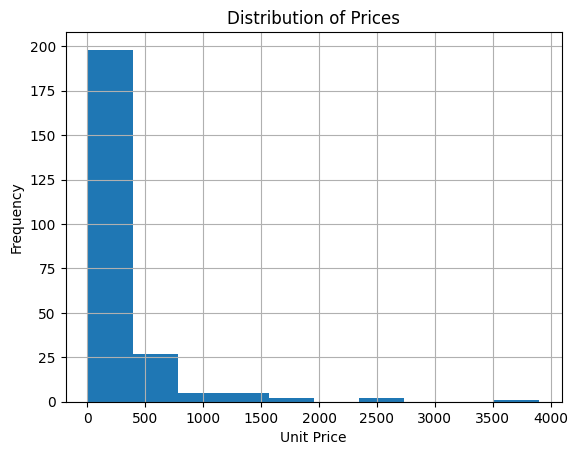

In [93]:
import matplotlib.pyplot as plt

df["Unit Price"].hist()
plt.title("Distribution of Prices")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

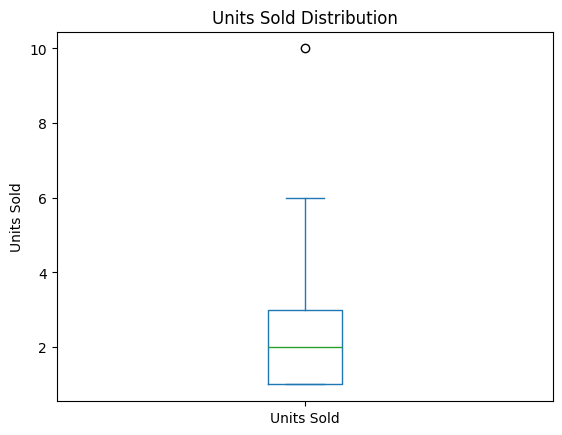

In [94]:
df["Units Sold"].plot(kind="box")

plt.title("Units Sold Distribution")
plt.ylabel("Units Sold")
plt.show()

## Task 1
In this section, the API key is securely loaded from a .env file using python-dotenv. Only the first 5 characters are printed for security reasons.


In [95]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("API_KEY")

print(api_key[:5] + "...")

62bbf...


## Task 2

### Task 2a
In this section, end-of-day stock data for FAANG companies is retrieved from the MarketStack API for March 2026.

In [96]:
import requests
import pandas as pd

symbols = ["META", "AAPL", "AMZN", "NFLX", "GOOG"]

url = "https://api.marketstack.com/v2/eod"

params = {
    "access_key": api_key,
    "symbols": ",".join(symbols),
    "date_from": "2026-03-01",
    "date_to": "2026-03-31",
    "sort": "ASC",
    "limit": 200
}

response = requests.get(url, params=params)
data = response.json()

data.keys()

dict_keys(['pagination', 'data'])

In [97]:
print(response.status_code)
print(data.get("pagination", {}))

200
{'limit': 200, 'offset': 0, 'count': 110, 'total': 110}


### Task 2b

In [98]:
df_faang = pd.DataFrame(data["data"])

df_faang["date"] = pd.to_datetime(df_faang["date"])
df_faang = df_faang.sort_values(["symbol", "date"]).reset_index(drop=True)

df_faang.head()

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,name,exchange_code,asset_type,price_currency,symbol,exchange,date
0,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-02 00:00:00+00:00
1,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-03 00:00:00+00:00
2,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-04 00:00:00+00:00
3,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-05 00:00:00+00:00
4,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-06 00:00:00+00:00


### Task 2c
In this section, summary statistics for closing prices are computed for each stock. 
Additionally, the percentage return over March 2026 is calculated to determine 
which stock performed best and worst.

In [99]:
# Group the data by stock symbol and compute summary statistics for closing prices
summary_stats = df_faang.groupby("symbol")["close"].describe()

# Display the summary statistics
summary_stats

,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


In [100]:
# For each stock, get the first and last closing price in March
monthly_returns = (
    df_faang.groupby("symbol")
    .agg(
        first_close=("close", "first"),   # first trading day price
        last_close=("close", "last")      # last trading day price
    )
)

# Calculate percentage return over the month
monthly_returns["return_pct"] = (
    (monthly_returns["last_close"] - monthly_returns["first_close"])
    / monthly_returns["first_close"]
) * 100

# Display the calculated returns
monthly_returns

,first_close,last_close,return_pct
symbol,,,
AAPL,264.72,253.79,-4.128891
AMZN,208.39,208.27,-0.057584
GOOG,306.36,286.86,-6.365061
META,653.56,572.13,-12.459453
NFLX,97.09,96.15,-0.968174


In [101]:
# Identify the best and worst performing stocks based on return percentage
best_stock = monthly_returns["return_pct"].idxmax()
worst_stock = monthly_returns["return_pct"].idxmin()

best_return = monthly_returns.loc[best_stock, "return_pct"]
worst_return = monthly_returns.loc[worst_stock, "return_pct"]

# Print results in a readable format
print(f"Best performing stock: {best_stock} ({best_return:.2f}%)")
print(f"Worst performing stock: {worst_stock} ({worst_return:.2f}%)")

Best performing stock: AMZN (-0.06%)
Worst performing stock: META (-12.46%)


## Task 3

### Task 3a

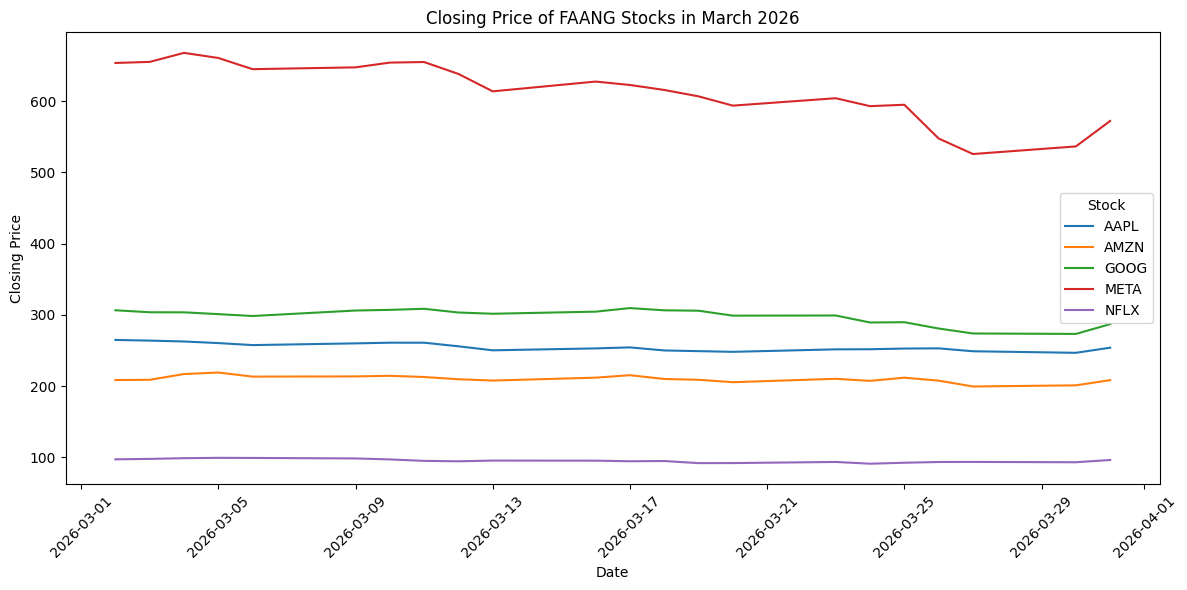

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_faang,
    x="date",
    y="close",
    hue="symbol"
)

plt.title("Closing Price of FAANG Stocks in March 2026")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.legend(title="Stock")
plt.tight_layout()
plt.show()

### Task 3b

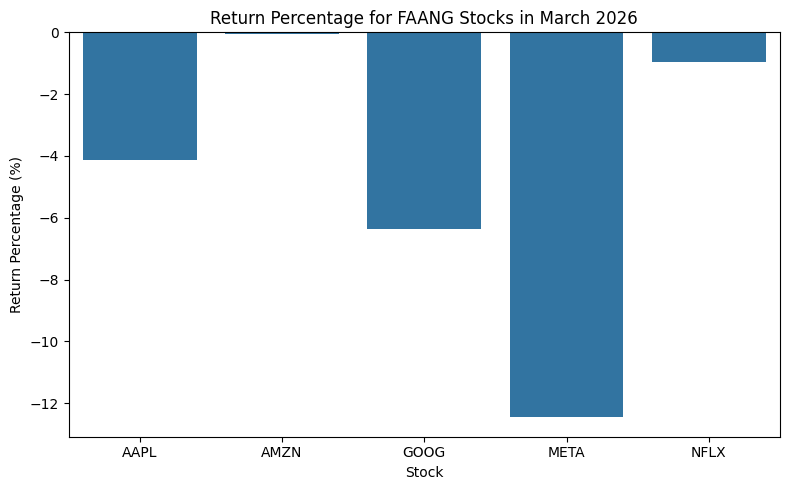

In [103]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=monthly_returns.reset_index(),
    x="symbol",
    y="return_pct"
)

plt.title("Return Percentage for FAANG Stocks in March 2026")
plt.xlabel("Stock")
plt.ylabel("Return Percentage (%)")

plt.tight_layout()
plt.show()

### Task 3c

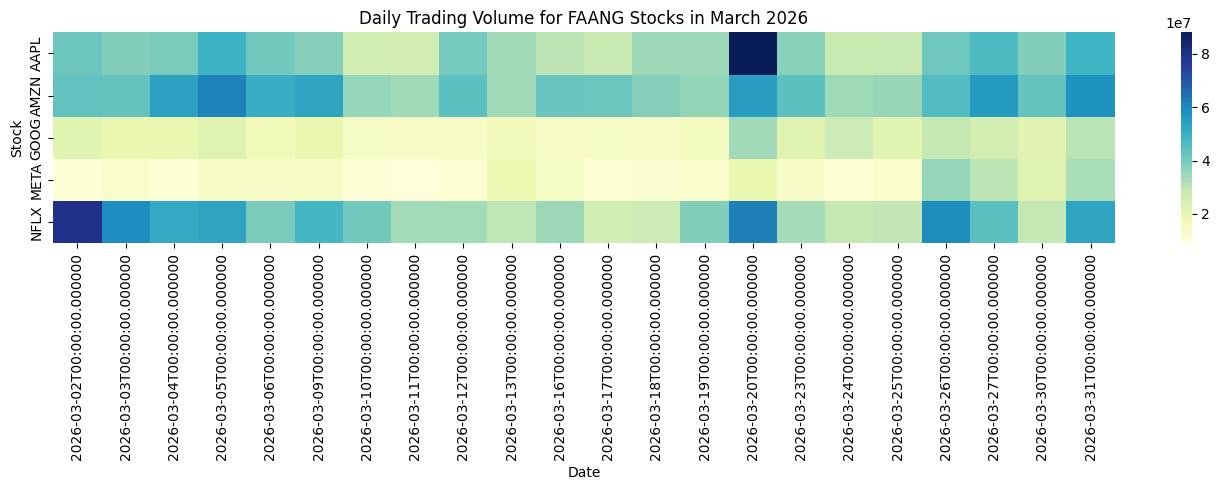

In [104]:
# Reshape data: rows = stocks, columns = dates, values = volume
volume_data = df_faang.pivot(
    index="symbol",
    columns="date",
    values="volume"
)

plt.figure(figsize=(14, 5))

sns.heatmap(
    volume_data,
    cmap="YlGnBu"
)

plt.title("Daily Trading Volume for FAANG Stocks in March 2026")
plt.xlabel("Date")
plt.ylabel("Stock")

plt.tight_layout()
plt.show()

## Task 4

### Task 4a

In [105]:
import os
import json

# Create exports folder if it doesn't exist
os.makedirs("exports", exist_ok=True)

# Save JSON data from Task 2a
with open("exports/stockdata.json", "w") as f:
    json.dump(data, f)

### Task 4b

In [106]:
# Save DataFrame from Task 2b
df_faang.to_csv("exports/stockdata.csv", index=False)

### Task 4c

In [107]:
# Load JSON file
with open("exports/stockdata.json", "r") as f:
    loaded_json = json.load(f)

# Convert JSON to DataFrame
df_json = pd.DataFrame(loaded_json["data"])

# Show first 5 rows
df_json.head()

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,name,exchange_code,asset_type,price_currency,symbol,exchange,date
0,262.44,266.53,260.20,264.72,41576035.0,266.53,260.20,264.72,262.410,41827946.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-02T00:00:00+0000
1,204.55,209.72,203.48,208.39,43410499.0,209.73,203.46,208.39,204.550,46001010.0,1.0,0.0,Amazon.com Inc,NASDAQ,Stock,USD,AMZN,XNAS,2026-03-02T00:00:00+0000
2,302.93,308.14,301.06,306.36,21789144.0,308.14,301.06,306.36,302.965,21854368.0,1.0,0.0,1X GOOG,NaN,ETF,EUR,GOOG,XNAS,2026-03-02T00:00:00+0000
3,637.16,659.94,634.50,653.56,9801700.0,659.94,634.50,653.56,637.160,9816125.0,1.0,0.0,"Meta Platforms, Inc.",NaN,Stock,ARS,META,ARCX,2026-03-02T00:00:00+0000
4,95.33,98.07,95.25,97.09,79614084.0,98.07,95.20,97.09,95.260,79915361.0,1.0,0.0,NETFLIX INC,NaN,NaN,MXN,NFLX,XNAS,2026-03-02T00:00:00+0000


In [108]:
# Load CSV file
df_csv = pd.read_csv("exports/stockdata.csv")

# Show first 5 rows
df_csv.head()

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,name,exchange_code,asset_type,price_currency,symbol,exchange,date
0,262.440,266.530,260.20,264.72,41576035.0,266.530,260.20,264.72,262.41,41827946.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-02 00:00:00+00:00
1,263.480,265.560,260.13,263.75,37994695.0,265.560,260.13,263.75,263.48,38568921.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-03 00:00:00+00:00
2,264.650,266.150,261.42,262.52,39258957.0,266.150,261.42,262.52,264.65,39803119.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-04 00:00:00+00:00
3,260.745,261.555,257.25,260.29,49424671.0,261.555,257.25,260.29,260.79,49658626.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-05 00:00:00+00:00
4,258.740,258.760,254.37,257.46,40628988.0,258.770,254.37,257.46,258.63,41120042.0,1.0,0.0,Apple Inc,NASDAQ,Stock,USD,AAPL,XNAS,2026-03-06 00:00:00+00:00


## Task 5

In [109]:
import sqlite3
import pandas as pd

### Task 5a

In [110]:
# Connect to the SQLite database
conn = sqlite3.connect("northwind.db")

# Query to list all tables in the database
query_tables = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql_query(query_tables, conn)
print(tables)

                    name
0             Categories
1        sqlite_sequence
2   CustomerCustomerDemo
3   CustomerDemographics
4              Customers
5              Employees
6    EmployeeTerritories
7          Order Details
8                 Orders
9               Products
10               Regions
11              Shippers
12             Suppliers
13           Territories


### Task 5b

In [111]:
query_products = """
SELECT ProductName, UnitPrice, UnitsInStock
FROM Products
WHERE UnitPrice > 30;
"""

products_df = pd.read_sql_query(query_products, conn)
print(products_df)

                   ProductName  UnitPrice  UnitsInStock
0   Northwoods Cranberry Sauce      40.00             6
1              Mishi Kobe Niku      97.00            29
2                        Ikura      31.00            31
3    Queso Manchego La Pastora      38.00            86
4                 Alice Mutton      39.00             0
5             Carnarvon Tigers      62.50            42
6       Sir Rodney's Marmalade      81.00            40
7          Gumbär Gummibärchen      31.23            15
8           Schoggi Schokolade      43.90            49
9            Rössle Sauerkraut      45.60            26
10     Thüringer Rostbratwurst     123.79             0
11          Mascarpone Fabioli      32.00             9
12               Côte de Blaye     263.50            17
13                 Ipoh Coffee      46.00            17
14       Manjimup Dried Apples      53.00            20
15               Perth Pasties      32.80             0
16      Gnocchi di nonna Alice      38.00       

### Taks 5c

In [112]:
query_germany = """
SELECT c.CompanyName,
       o.OrderID,
       o.OrderDate,
       o.ShipCountry,
       od.UnitPrice * od.Quantity AS LineTotal
FROM Orders o
JOIN Customers c ON o.CustomerID = c.CustomerID
JOIN "Order Details" od ON o.OrderID = od.OrderID
WHERE o.ShipCountry = 'Germany';
"""

germany_orders_df = pd.read_sql_query(query_germany, conn)
print(germany_orders_df)

              CompanyName  OrderID            OrderDate ShipCountry  LineTotal
0      Toms Spezialitäten    10249           2016-07-05     Germany      167.4
1      Toms Spezialitäten    10249           2016-07-05     Germany     1696.0
2      Ottilies Käseladen    10260           2016-07-19     Germany      123.2
3      Ottilies Käseladen    10260           2016-07-19     Germany      780.0
4      Ottilies Käseladen    10260           2016-07-19     Germany      591.0
...                   ...      ...                  ...         ...        ...
80668    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany      864.0
80669    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany      735.0
80670    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany       75.0
80671    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany      500.0
80672    Comércio Mineiro    26519  2022-08-26 16:17:42     Germany       77.5

[80673 rows x 5 columns]


In [113]:
conn.close()
# To close the connection to the database

## Task 6

### Task 6a
Bar plot showing the number of orders per customer for the top 10 customers who shipped to Germany.

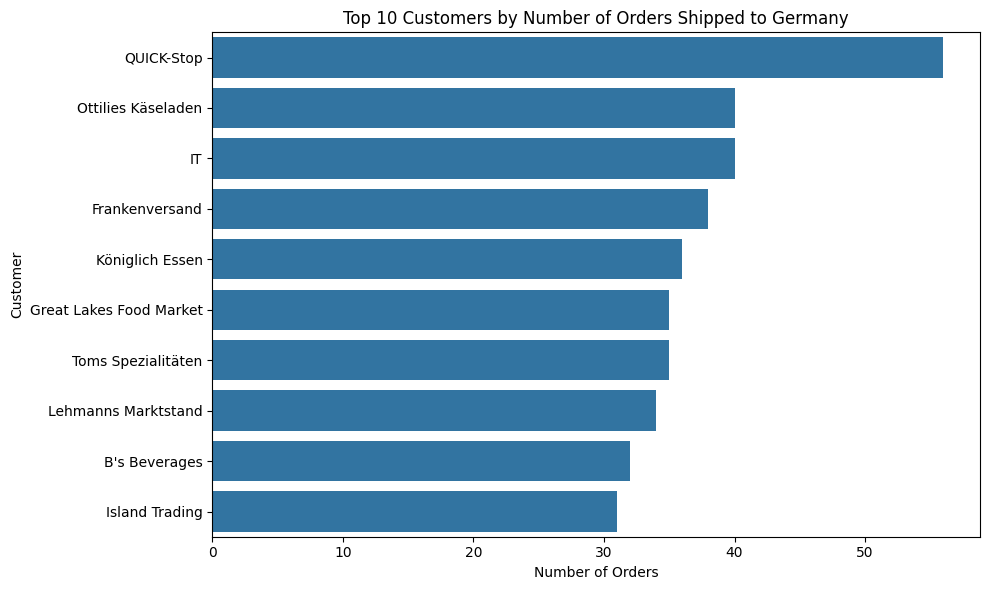

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count unique orders per customer
orders_per_customer = (
    germany_orders_df.groupby("CompanyName")["OrderID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="OrderCount")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=orders_per_customer,
    x="OrderCount",
    y="CompanyName"
)

plt.title("Top 10 Customers by Number of Orders Shipped to Germany")
plt.xlabel("Number of Orders")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

### Task 6b
Density plot showing the distribution of daily total sales for orders shipped to Germany.

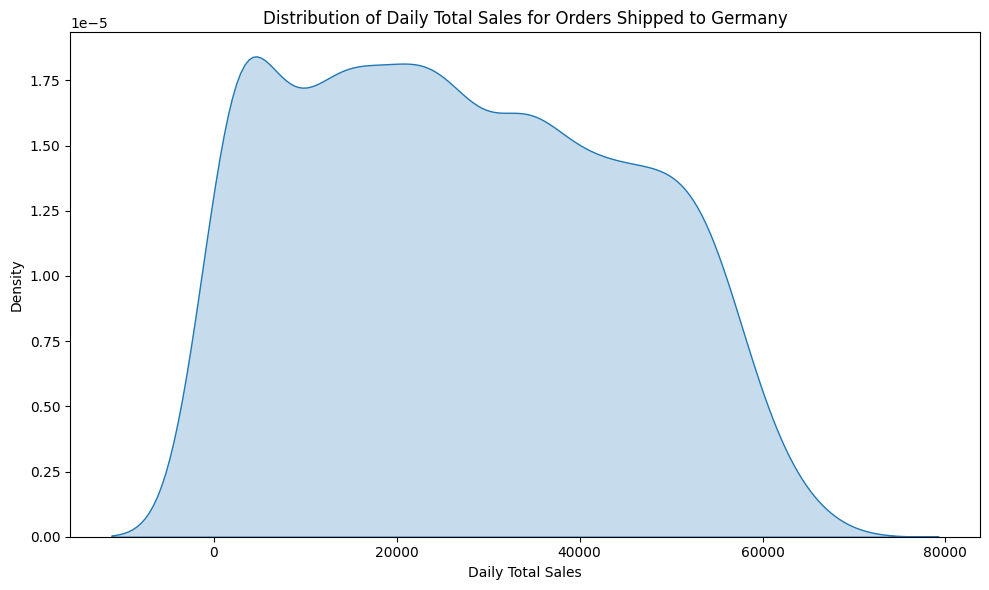

In [115]:
# Convert OrderDate to datetime
germany_orders_df["OrderDate"] = pd.to_datetime(
    germany_orders_df["OrderDate"],
    format="mixed"
)

# Compute total sales per order date
daily_sales = (
    germany_orders_df.groupby("OrderDate")["LineTotal"]
    .sum()
    .reset_index(name="DailySales")
)

plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=daily_sales,
    x="DailySales",
    fill=True
)

plt.title("Distribution of Daily Total Sales for Orders Shipped to Germany")
plt.xlabel("Daily Total Sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

### Task 6c
Bar plot showing total revenue by product category.

In [116]:
# Reconnect to the database if needed
conn = sqlite3.connect("northwind.db")

query_category_revenue = """
SELECT c.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories c ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
ORDER BY TotalRevenue DESC;
"""

category_revenue_df = pd.read_sql_query(query_category_revenue, conn)

print(category_revenue_df)

     CategoryName  TotalRevenue
0       Beverages   92181842.95
1     Confections   66347544.94
2    Meat/Poultry   64896314.41
3  Dairy Products   58034940.00
4      Condiments   55802774.45
5         Seafood   49931965.52
6         Produce   32706403.90
7  Grains/Cereals   28573512.55


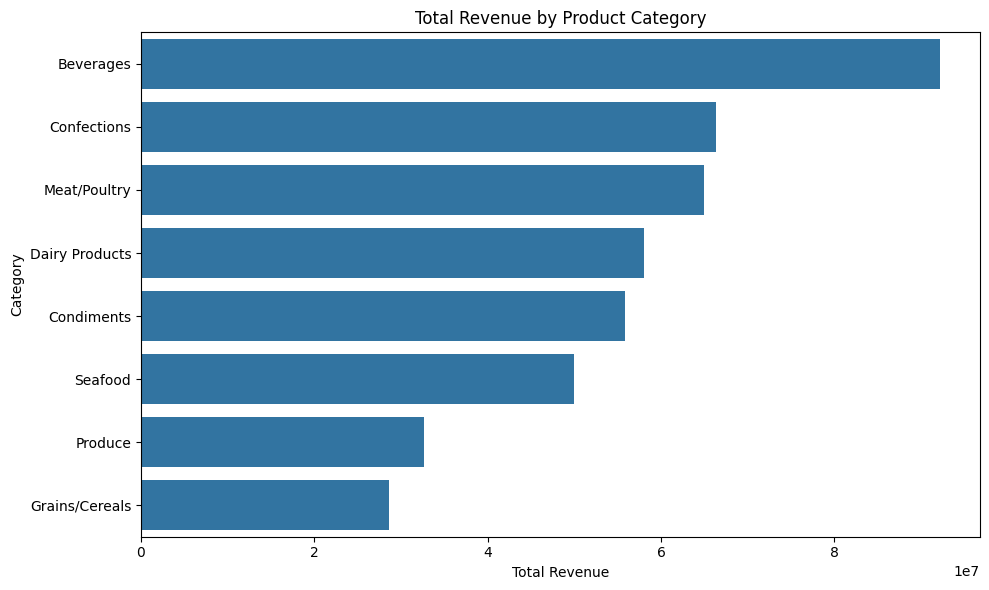

In [117]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_revenue_df,
    x="TotalRevenue",
    y="CategoryName"
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [118]:
conn.close()

## Task 7

### Task 7a
Load the full Products and Categories tables into separate DataFrames.
Last is just "pictures in the data base"

In [119]:
import sqlite3
import pandas as pd
import time

# Connect to the database
conn = sqlite3.connect("northwind.db")

# Load full Products table
products_df = pd.read_sql_query("SELECT * FROM Products;", conn)

# Load full Categories table
ccategories_df = pd.read_sql_query("""
SELECT CategoryID, CategoryName, Description
FROM Categories;
""", conn)

# Show first 5 rows of each table
print("Products table:")
print(products_df.head())

print("\nCategories table:")
print(categories_df.head())

Products table:
   ProductID                   ProductName  SupplierID  CategoryID  \
0          1                          Chai           1           1   
1          2                         Chang           1           1   
2          3                 Aniseed Syrup           1           2   
3          4  Chef Anton's Cajun Seasoning           2           2   
4          5        Chef Anton's Gumbo Mix           2           2   

       QuantityPerUnit  UnitPrice  UnitsInStock  UnitsOnOrder  ReorderLevel  \
0   10 boxes x 20 bags      18.00            39             0            10   
1   24 - 12 oz bottles      19.00            17            40            25   
2  12 - 550 ml bottles      10.00            13            70            25   
3       48 - 6 oz jars      22.00            53             0             0   
4             36 boxes      21.35             0             0             0   

  Discontinued  
0            0  
1            0  
2            0  
3            0  
4  

### Task 7b
Perform an inner join in pandas on CategoryID.

In [120]:
products_categories_df = pd.merge(
    products_df,
    categories_df,
    on="CategoryID",
    how="inner"
)

products_categories_df.head()


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


### Task 7c
Compare performing the join and aggregation in SQL versus in Python with pandas.

In [121]:
start_sql = time.time()

query_sql = """
SELECT c.CategoryName,
       SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
FROM "Order Details" od
JOIN Products p ON od.ProductID = p.ProductID
JOIN Categories c ON p.CategoryID = c.CategoryID
GROUP BY c.CategoryName
ORDER BY TotalRevenue DESC;
"""

sql_result_df = pd.read_sql_query(query_sql, conn)

end_sql = time.time()
sql_time = end_sql - start_sql

print("SQL result:")
print(sql_result_df)
print(f"\nSQL execution time: {sql_time:.6f} seconds")

SQL result:
     CategoryName  TotalRevenue
0       Beverages   92181842.95
1     Confections   66347544.94
2    Meat/Poultry   64896314.41
3  Dairy Products   58034940.00
4      Condiments   55802774.45
5         Seafood   49931965.52
6         Produce   32706403.90
7  Grains/Cereals   28573512.55

SQL execution time: 0.513523 seconds


In [122]:
start_python = time.time()

# Load full tables from SQL
order_details_df = pd.read_sql_query('SELECT * FROM "Order Details";', conn)
products_df = pd.read_sql_query("SELECT * FROM Products;", conn)
categories_df = pd.read_sql_query("SELECT * FROM Categories;", conn)

# Merge Order Details with Products
merged_df = pd.merge(
    order_details_df,
    products_df,
    on="ProductID",
    how="inner"
)

# Merge with Categories
merged_df = pd.merge(
    merged_df,
    categories_df,
    on="CategoryID",
    how="inner"
)

# Compute line revenue
merged_df["LineRevenue"] = merged_df["UnitPrice_x"] * merged_df["Quantity"]

# Group by category and sum revenue
python_result_df = (
    merged_df.groupby("CategoryName", as_index=False)["LineRevenue"]
    .sum()
    .rename(columns={"LineRevenue": "TotalRevenue"})
    .sort_values("TotalRevenue", ascending=False)
)

end_python = time.time()
python_time = end_python - start_python

print("Python/pandas result:")
print(python_result_df)
print(f"\nPython execution time: {python_time:.6f} seconds")

Python/pandas result:
     CategoryName  TotalRevenue
0       Beverages   92181842.95
2     Confections   66347544.94
5    Meat/Poultry   64896314.41
3  Dairy Products   58034940.00
1      Condiments   55802774.45
7         Seafood   49931965.52
6         Produce   32706403.90
4  Grains/Cereals   28573512.55

Python execution time: 1.780190 seconds


In [123]:
print(f"SQL execution time: {sql_time:.6f} seconds")
print(f"Python execution time: {python_time:.6f} seconds")

SQL execution time: 0.513523 seconds
Python execution time: 1.780190 seconds


### Comment

The SQL approach was faster because the joins and aggregation were performed directly inside the database engine.  
The pandas approach required loading the full tables into Python first and then performing the joins and calculations in memory, which adds overhead.

## Task 8

In [124]:
import pandas as pd

wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

### Task 8a
Convert wide_data from wide to long format using pd.melt().

In [125]:
print("Wide data before conversion:")
print(wide_data)

wide_to_long = pd.melt(
    wide_data,
    id_vars="store",
    var_name="quarter",
    value_name="sales"
)

print("\nWide data after conversion to long format:")
print(wide_to_long)

Wide data before conversion:
      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500

Wide data after conversion to long format:
       store   quarter  sales
0   Helsinki  Q1_sales  12000
1    Tampere  Q1_sales   8500
2      Turku  Q1_sales   9200
3   Helsinki  Q2_sales  13500
4    Tampere  Q2_sales   9100
5      Turku  Q2_sales   9800
6   Helsinki  Q3_sales  11800
7    Tampere  Q3_sales   8800
8      Turku  Q3_sales  10100
9   Helsinki  Q4_sales  15000
10   Tampere  Q4_sales  10200
11     Turku  Q4_sales  11500


### Task 8b
Convert long_data from long to wide format using pivot().

In [126]:
print("Long data before conversion:")
print(long_data)

long_to_wide = long_data.pivot(
    index="month",
    columns="product",
    values="units_sold"
)

print("\nLong data after conversion to wide format:")
print(long_to_wide)

Long data before conversion:
  month product  units_sold
0   Jan  Laptop          45
1   Jan   Phone         120
2   Feb  Laptop          50
3   Feb   Phone         110
4   Mar  Laptop          55
5   Mar   Phone         130

Long data after conversion to wide format:
product  Laptop  Phone
month                 
Feb          50    110
Jan          45    120
Mar          55    130


### Task 8c
Convert both transformed datasets back to their original format.

In [127]:
wide_restored = wide_to_long.pivot(
    index="store",
    columns="quarter",
    values="sales"
).reset_index()

# Remove the column index name to make it look cleaner
wide_restored.columns.name = None

print("Wide-format data restored from long format:")
print(wide_restored)

Wide-format data restored from long format:
      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500


In [128]:
long_restored = long_to_wide.reset_index().melt(
    id_vars="month",
    var_name="product",
    value_name="units_sold"
)

# Sort rows so the order is easier to compare with the original
long_restored = long_restored.sort_values(["month", "product"]).reset_index(drop=True)

print("\nLong-format data restored from wide format:")
print(long_restored)


Long-format data restored from wide format:
  month product  units_sold
0   Feb  Laptop          50
1   Feb   Phone         110
2   Jan  Laptop          45
3   Jan   Phone         120
4   Mar  Laptop          55
5   Mar   Phone         130


In [129]:
print("Original wide_data:")
print(wide_data)

print("\nRestored wide_data:")
print(wide_restored)

print("\nOriginal long_data:")
print(long_data)

print("\nRestored long_data:")
print(long_restored)

Original wide_data:
      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500

Restored wide_data:
      store  Q1_sales  Q2_sales  Q3_sales  Q4_sales
0  Helsinki     12000     13500     11800     15000
1   Tampere      8500      9100      8800     10200
2     Turku      9200      9800     10100     11500

Original long_data:
  month product  units_sold
0   Jan  Laptop          45
1   Jan   Phone         120
2   Feb  Laptop          50
3   Feb   Phone         110
4   Mar  Laptop          55
5   Mar   Phone         130

Restored long_data:
  month product  units_sold
0   Feb  Laptop          50
1   Feb   Phone         110
2   Jan  Laptop          45
3   Jan   Phone         120
4   Mar  Laptop          55
5   Mar   Phone         130


## AI Comments

### Comments
AI was used to help with error messages and to fix small bugs